# Analysis for the $\sin$ benchmark

The datasets considered as follows.

1. `sin-noise-0`:
    Each $x_j$ is selected uniformly at random between $-\pi$ and $\pi$, $j = 1 \dots 100$.
    Then $y_j = \sin x_j$.
2. `sin-noise-1`:
    Same process as `sin-noise-0` but $y_j = \sin x_j + \eta_j$ where $\eta_j$ has a normal distribution with mean $0$ and standard deviation $0.1$.

## Prelude

In [1]:
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import sympy

import AnalysisUtils as au

In [3]:
def lambda_op_plot(
    data,
    spiffy_titles=None,
    complexity_col="complexity",
    mse_col="mse",
    complexity_binwidth=10,
    mse_binwidth=0.02,
    complexity_lims=(0, 169),
    mse_lims=(6e-5, 1.1e-4),
    mse_bound=1e-4,
    picture_dir=Path("Generated/Pictures"),
    file_stem=None,
    **kwargs
):
    mse_lims_log = (np.log10(mse_lims[0]), np.log10(mse_lims[1]))
    fig = sns.displot(
        data,
        x=complexity_col,
        y=mse_col,
        col="Lopstr",
        log_scale=[False, True],
        binwidth=(complexity_binwidth, mse_binwidth),
        binrange=(complexity_lims, mse_lims_log),
    )
    # Add a horizontal line for the MSE bound in each subplot
    for ax in fig.axes.flat:
        ax.axhline(y=mse_bound, color="red", linestyle="--", label="MSE bound")
    fig.set(xlim=complexity_lims, ylim=mse_lims)
    if spiffy_titles is not None:
        for ax, title in zip(fig.axes.flat, spiffy_titles):
            ax.set_title(title)
    fig.set(**kwargs)
    au.savefig(fig, file_stem=file_stem, picture_dir=picture_dir)
    return fig

## Loading data

These are the datasets to be fit.

In [4]:
sn0 = pd.read_csv("datasets/sin-noise-0.csv")
sn1 = pd.read_csv("datasets/sin-noise-1.csv")

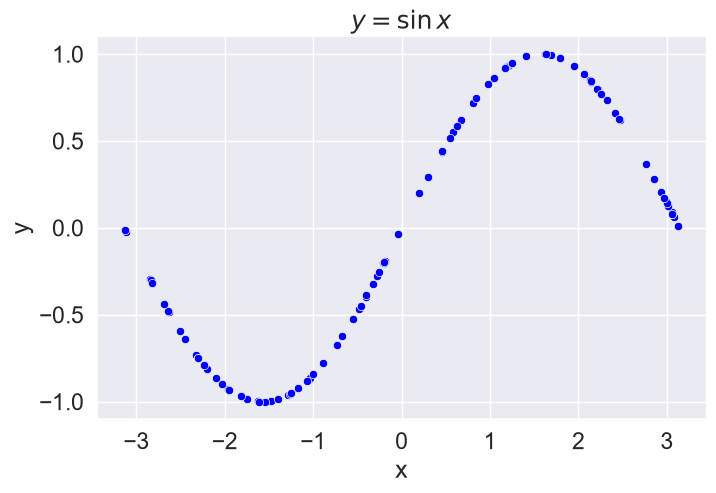

In [5]:
fig = sns.relplot(data=sn0, x="x", y="y", color="blue", aspect=1.5)
fig.set(title=r"$y = \sin x$")
au.savefig(fig, file_stem="sin-noise-0")

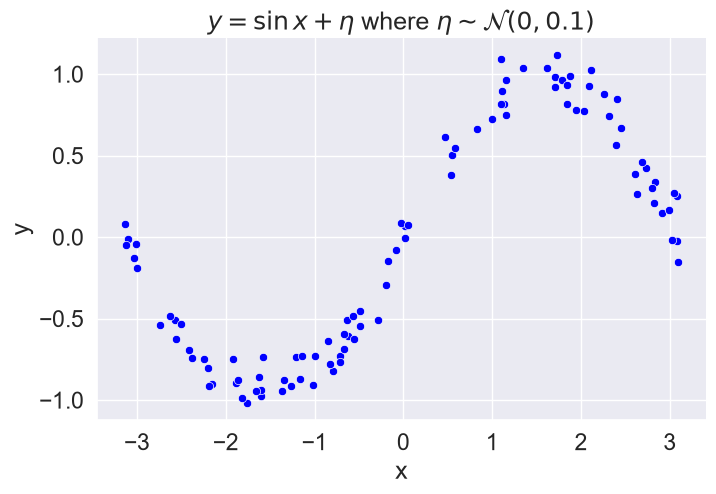

In [6]:
fig = sns.relplot(data=sn1, x="x", y="y", color="blue", aspect=1.5)
fig.set(title=r"$y = \sin x + \eta$ where $\eta \sim \mathcal{N}(0, 0.1)$")
au.savefig(fig, file_stem="sin-noise-01")

These are the results of Jessamine symbolic regression.

In [7]:
full_report = pd.read_csv("For-analysis/full-report.csv")

In [8]:
full_report["sympy"] = full_report.expr_original_syms.apply(au.parse_if_needed)
full_report["sympy_defuzz"] = full_report.expr_original_syms_defuzz.apply(au.parse_if_needed)

In [9]:
full_report.run_set.unique()

<StringArray>
['SRB-2026-06-25-1715', 'SRB-2026-06-25-1715-L2', 'SRB-2026-06-25-1715-L4']
Length: 3, dtype: str

In [10]:
full_report.data_set.unique()

<StringArray>
['sin-noise-0', 'sin-noise-1', 'sin-noise-2']
Length: 3, dtype: str

In [11]:
full_report.sort_values(by=["run_set", "data_set", "mse"], inplace=True)

srb_key_base = "SRB-2026-06-25-1715"

srb_keys = [srb_key_base, srb_key_base + "-L4", srb_key_base + "-L2"]

Lop12 = 1.0e-12
Lop4 = 1.0e-4
Lop2 = 1.0e-2
full_report.loc[full_report.run_set=="SRB-2026-06-25-1715", "Lop"] = Lop12
full_report.loc[full_report.run_set=="SRB-2026-06-25-1715-L4", "Lop"] = Lop4
full_report.loc[full_report.run_set=="SRB-2026-06-25-1715-L2", "Lop"] = Lop2

# These have to be strings because they need to be exact categorical labels for plotting
spiffy_Lopstr12 = r"$\lambda = 10^{-12}$"
spiffy_Lopstr4 = r"$\lambda = 10^{-4}$"
spiffy_Lopstr2 = r"$\lambda = 10^{-2}$"
Lopstr12 = "L0000"
Lopstr4 = "L0001"
Lopstr2 = "L0100"
full_report.loc[full_report.run_set==srb_key_base, "Lopstr"] = Lopstr12
full_report.loc[full_report.run_set==srb_key_base+"-L4", "Lopstr"] = Lopstr4
full_report.loc[full_report.run_set==srb_key_base+"-L2", "Lopstr"] = Lopstr2


In [12]:
fr1 = full_report.copy()
fr1 = fr1.loc[fr1.data_set.isin(['sin-noise-0', 'sin-noise-1'])]

# Normalize the run set
fr1.loc[fr1.run_set==srb_key_base+"-L4", "run_set"] = srb_key_base
fr1.loc[fr1.run_set==srb_key_base+"-L2", "run_set"] = srb_key_base

fr1.set_index(["run_set", "Lopstr"], inplace=True)
fr1.sort_index(inplace=True)
srb_fr = fr1.loc[srb_key_base]

In [13]:
fr1

data_set  sample_num        rating  \
run_set             Lopstr                                          
SRB-2026-06-25-1715 L0000   sin-noise-0           4  2.000000e-12   
                    L0000   sin-noise-0          20  2.000000e-12   
                    L0000   sin-noise-0           1  2.000000e-12   
                    L0000   sin-noise-0           2  2.000000e-12   
                    L0000   sin-noise-0           3  2.000000e-12   
...                                 ...         ...           ...   
                    L0100   sin-noise-1          28  1.985803e-02   
                    L0100   sin-noise-1          29  1.985803e-02   
                    L0100   sin-noise-1          30  1.985803e-02   
                    L0100   sin-noise-1          31  1.985803e-02   
                    L0100   sin-noise-1          32  1.985803e-02   

                                     mse  complexity  complexity_defuzz  \
run_set             Lopstr                                                
SRB-2026-06-25-1715 L0000   2.092210e-28           4                  2   
                    L0000   2.092801e-28           6                  2   
                    L0000   2.092860e-28           6                  2   
                    L0000   2.092860e-28           6                  2   
                    L0000   2.092860e-28           6                  2   
...                                  ...         ...                ...   
                    L0100   9.858035e-03           6                  6   
                    L0100   9.858035e-03           6                  6   
                    L0100   9.858035e-03           6                  6   
                    L0100   9.858035e-03           6                  6   
                    L0100   9.858035e-03           6                  6   

                                                                         expr  \
run_set             Lopstr                                                      
SRB-2026-06-25-1715 L0000                           0.999999999999979*sin(x1)   
                    L0000    0.999999999999979*sin(x1) - 6.77790464694725e-17   
                    L0000   0.999999999999979*sin(x1) - 8.036157408189007e-17   
                    L0000   0.999999999999979*sin(x1) - 7.997664597095252e-17   
                    L0000   0.999999999999979*sin(x1) - 7.997664597095312e-17   
...                                                                       ...   
                    L0100   0.9739867134223519*sin(x1) + 0.001002835949261577   
                    L0100   0.9739867134223519*sin(x1) + 0.001002835949261577   
                    L0100   0.9739867134223519*sin(x1) + 0.001002835949261577   
                    L0100   0.9739867134223518*sin(x1) + 0.001002835949261...   
                    L0100   0.9739867134223518*sin(x1) + 0.001002835949261...   

                                                                expr_defuzz  \
run_set             Lopstr                                                    
SRB-2026-06-25-1715 L0000                                           sin(x1)   
                    L0000                                           sin(x1)   
                    L0000                                           sin(x1)   
                    L0000                                           sin(x1)   
                    L0000                                           sin(x1)   
...                                                                     ...   
                    L0100   0.973986713422352*sin(x1) + 0.00100283594926158   
                    L0100   0.973986713422352*sin(x1) + 0.00100283594926158   
                    L0100   0.973986713422352*sin(x1) + 0.00100283594926158   
                    L0100   0.973986713422352*sin(x1) + 0.00100283594926157   
                    L0100   0.973986713422352*sin(x1) + 0.00100283594926157   

                                                           expr_original_sy

In [14]:
results_sn0 = srb_fr.loc[srb_fr.data_set == "sin-noise-0"]
results_sn1 = srb_fr.loc[srb_fr.data_set == "sin-noise-1"]

## For reference

Symbolic regression is fitting noise if it gets MSE any lower than these.

In [15]:
sn0_mse_bound = au.mse(np.sin(sn0.x), sn0.y)
sn1_mse_bound = au.mse(np.sin(sn1.x), sn1.y)


## Analysis of results from the narrow datasets

### One period, zero noise

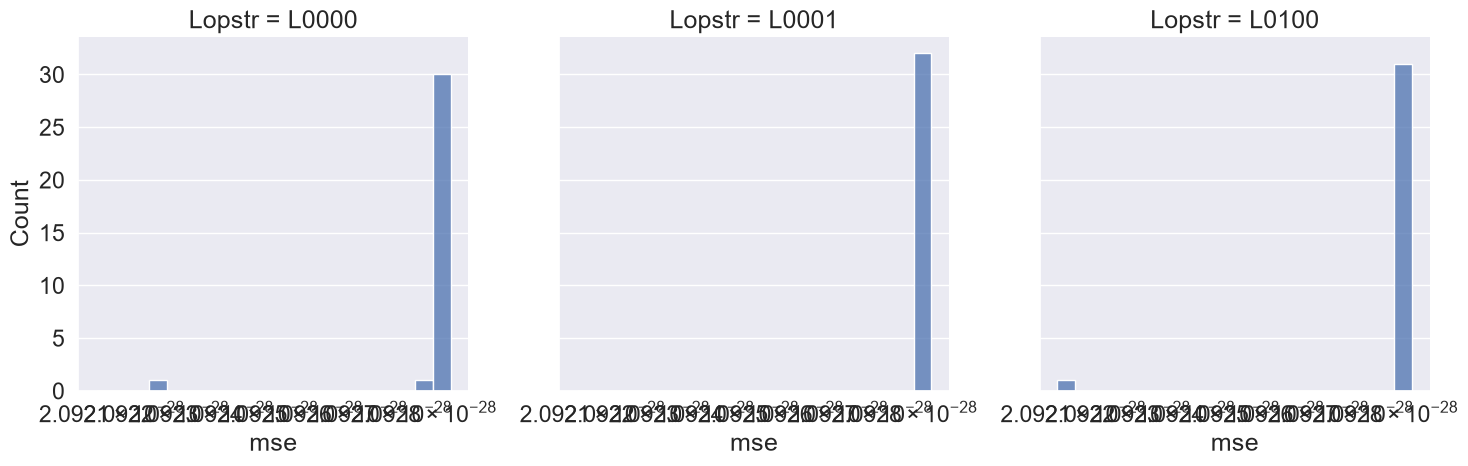

In [16]:
sns.displot(data=results_sn0, x="mse", col="Lopstr", log_scale=True)

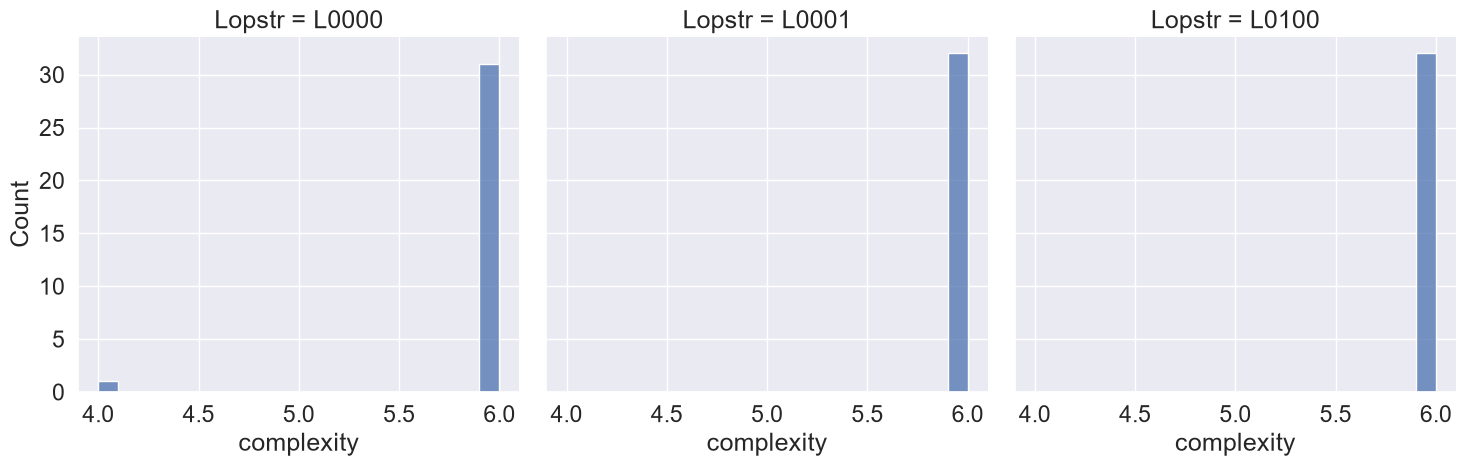

In [17]:
sns.displot(data=results_sn0, x="complexity", col="Lopstr")

With no noise, the function $\sin x$ is recovered every time, apart from fuzz.

### One period, high noise

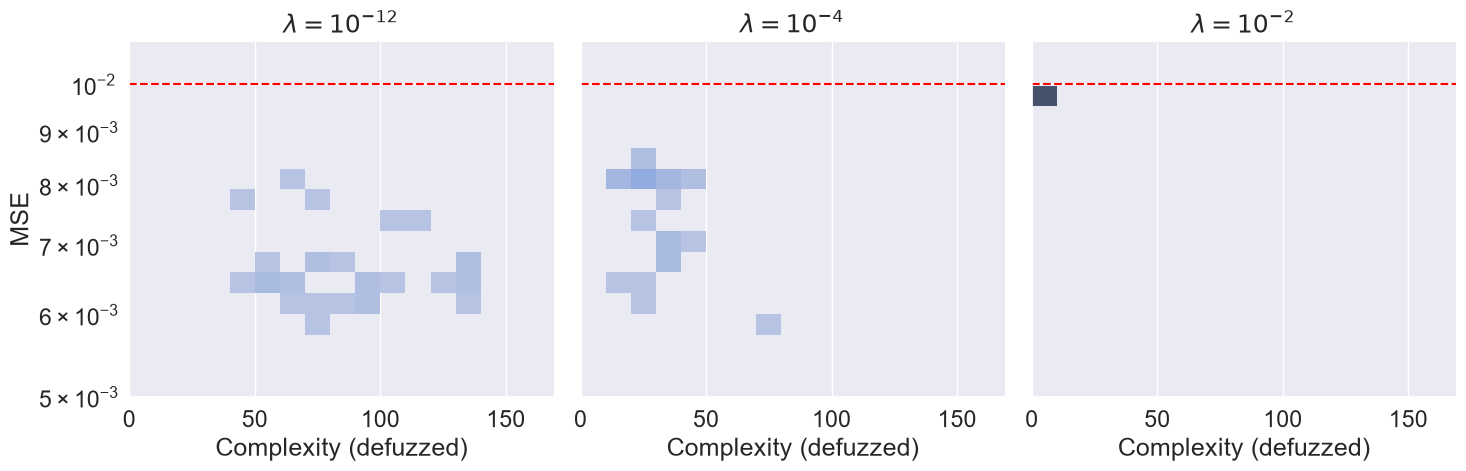

In [18]:
lambda_op_plot(
    results_sn1,
    file_stem="trig-sin-noise-01-complexity-mse-displot",
    mse_lims=(5e-3, 1.1e-2),
    complexity_lims=(0, 169),
    mse_bound=0.01,
    complexity_col="complexity_defuzz",
    spiffy_titles=[spiffy_Lopstr12, spiffy_Lopstr4, spiffy_Lopstr2],
    xlabel="Complexity (defuzzed)",
    ylabel="MSE",
)

In [19]:
au.count_by_threshold(results_sn1, 0.9*sn1_mse_bound, groupby="Lopstr")

Lopstr
L0000    32
L0001    32
L0100     0
Name: mse, dtype: int64

In [20]:
results_sn1.loc[Lopstr12].sort_values(by="mse")

,data_set,sample_num,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz,Lop
Lopstr,,,,,,,,,,,,,
L0000,sin-noise-1,1,0.005987,0.005987,80,76,0.2703882208954242*x1 + 0.014617941591526273*(...,0.270388220895424*x1 + 0.0146179415915263*(-1....,0.2703882208954242*x + 0.014617941591526273*(-...,0.270388220895424*x + 0.0146179415915263*(-1.0...,0.2703882208954242*x + 0.014617941591526273*(-...,0.270388220895424*x + 0.0146179415915263*(-1.0...,1.000000e-12
L0000,sin-noise-1,32,0.006059,0.006061,131,131,-0.35655023603983017*x1 - 0.050826169883401628...,-0.35655023603983*x1 - 0.0508261698834016*exp(...,-0.35655023603983017*x - 0.050826169883401628*...,-0.35655023603983*x - 0.0508261698834016*exp(x...,-0.35655023603983017*x - 0.050826169883401628*...,-0.35655023603983*x - 0.0508261698834016*exp(x...,1.000000e-12
L0000,sin-noise-1,18,0.006064,0.006064,100,85,0.009099948376851833*x1**2 + 0.034752843024139...,0.00909994837685183*x1**2 + 0.0347528430241393...,0.009099948376851833*x**2 + 0.0347528430241392...,0.00909994837685183*x**2 + 0.0347528430241393*...,0.009099948376851833*x**2 + 0.0347528430241392...,0.00909994837685183*x**2 + 0.0347528430241393*...,1.000000e-12
L0000,sin-noise-1,21,0.006165,0.006201,86,76,0.012990110057996485*x1 - 4.520666426517158e-6...,0.0129901100579965*x1 + 0.0129901100579965*(si...,0.012990110057996485*x - 4.520666426517158e-6*...,0.0129901100579965*x + 0.0129901100579965*(sin...,0.012990110057996485*x - 4.520666426517158e-6*...,0.0129901100579965*x + 0.0129901100579965*(sin...,1.000000e-12
L0000,sin-noise-1,4,0.006216,0.006216,85,62,-2.379520662253237e-6*x1**9 + 0.00150077064365...,0.00150077064365411*x1**3 - 0.0014981872847060...,-2.379520662253237e-6*x**9 + 0.001500770643654...,0.00150077064365411*x**3 - 0.00149818728470608...,-2.379520662253237e-6*x**9 + 0.001500770643654...,0.00150077064365411*x**3 - 0.00149818728470608...,1.000000e-12
L0000,sin-noise-1,7,0.006218,0.006218,139,96,0.0006848555795252377*x1**3 + 0.00012163779905...,0.000684855579525238*x1**3 + 0.000121637799050...,0.0006848555795252377*x**3 + 0.000121637799050...,0.000684855579525238*x**3 + 0.0001216377990500...,0.0006848555795252377*x**3 + 0.000121637799050...,0.000684855579525238*x**3 + 0.0001216377990500...,1.000000e-12
L0000,sin-noise-1,25,0.006265,0.006265,114,95,-0.003086897049070872*x1*exp(x1) - 0.138729969...,-0.00308689704907087*x1*exp(x1) - 0.1387299691...,-0.003086897049070872*x*exp(x) - 0.13872996916...,-0.00308689704907087*x*exp(x) - 0.138729969161...,-0.003086897049070872*x*exp(x) - 0.13872996916...,-0.00308689704907087*x*exp(x) - 0.138729969161...,1.000000e-12
L0000,sin-noise-1,8,0.006343,0.006343,84,56,0.001617918319780312*x1**3 - 0.001617918319780...,0.00161791831978031*x1**3 - 0.0016179183197803...,0.001617918319780312*x**3 - 0.0016179183197803...,0.00161791831978031*x**3 - 0.00161791831978031...,0.001617918319780312*x**3 - 0.0016179183197803...,0.00161791831978031*x**3 - 0.00161791831978031...,1.000000e-12
L0000,sin-noise-1,12,0.006351,0.006351,170,101,-5.712187021655504e-38*x1*((x1 + 1.00995057257...,-0.0668606753831164*exp(cos(x1 + 0.00033683974...,-5.712187021655504e-38*x*((x + 1.0099505725740...,-0.0668606753831164*exp(cos(x + 0.000336839742...,-5.712187021655504e-38*x*((x + 1.0099505725740...,-0.0668606753831164*exp(cos(x + 0.000336839742...,1.000000e-12


The `Lopstr12` runs are mostly wrong symbolically but accurate numerically.

In [21]:
results_sn1.loc[Lopstr4].sort_values(by="mse")

,data_set,sample_num,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz,Lop
Lopstr,,,,,,,,,,,,,
L0001,sin-noise-1,17,0.008342,0.005942,94,78,5.6713797460676986e-8*sqrt(1.05399600274175*ex...,-0.00294891913911954*(-sin(cos(2*x1) - 0.05258...,5.6713797460676986e-8*sqrt(1.05399600274175*ex...,-0.00294891913911954*(-sin(cos(2*x) - 0.052588...,5.6713797460676986e-8*sqrt(1.05399600274175*ex...,-0.00294891913911954*(-sin(cos(2*x) - 0.052588...,0.0001
L0001,sin-noise-1,24,0.008493,0.006294,36,25,-3.0423081672003049e-35*exp(3*x1 + 3.061863107...,1.00588358798123*sin(x1) - 0.0286067507327787*...,-3.0423081672003049e-35*exp(3*x + 3.0618631079...,1.00588358798123*sin(x) - 0.0286067507327787*s...,-3.0423081672003049e-35*exp(3*x + 3.0618631079...,1.00588358798123*sin(x) - 0.0286067507327787*s...,0.0001
L0001,sin-noise-1,20,0.008412,0.006514,41,19,-4.997116992794836e-39*exp(3*(x1 - 0.004584373...,1.04045823684799*sin(x1) - 0.114829771871138*s...,-4.997116992794836e-39*exp(3*(x - 0.0045843733...,1.04045823684799*sin(x) - 0.114829771871138*si...,-4.997116992794836e-39*exp(3*(x - 0.0045843733...,1.04045823684799*sin(x) - 0.114829771871138*si...,0.0001
L0001,sin-noise-1,27,0.007784,0.006584,27,27,0.9292512883978468*sin(x1) - 0.089891363284840...,0.929251288397847*sin(x1) - 0.0898913632848401...,0.9292512883978468*sin(x) - 0.0898913632848400...,0.929251288397847*sin(x) - 0.0898913632848401*...,0.9292512883978468*sin(x) - 0.0898913632848400...,0.929251288397847*sin(x) - 0.0898913632848401*...,0.0001
L0001,sin-noise-1,9,0.008472,0.006672,47,39,-0.001279087508506893*(x1 - 0.0094414465538453...,-0.00127908750850689*(x1 - 0.00944144655384534...,-0.001279087508506893*(x - 0.00944144655384534...,-0.00127908750850689*(x - 0.00944144655384534)...,-0.001279087508506893*(x - 0.00944144655384534...,-0.00127908750850689*(x - 0.00944144655384534)...,0.0001
L0001,sin-noise-1,14,0.007997,0.006796,34,32,-12.097641041958765*sqrt(sin(x1) + cos(1) + 2....,-12.0976410419588*(sin(x1) + 2.54030230586814)...,-12.097641041958765*sqrt(sin(x) + cos(1) + 2.0...,-12.0976410419588*(sin(x) + 2.54030230586814)*...,-12.097641041958765*sqrt(sin(x) + cos(1) + 2.0...,-12.0976410419588*(sin(x) + 2.54030230586814)*...,0.0001
L0001,sin-noise-1,1,0.007960,0.006860,35,35,0.0015678176012969992*x1**3 + 0.99504789640129...,0.001567817601297*x1**3 + 0.995047896401294*si...,0.0015678176012969992*x**3 + 0.995047896401294...,0.001567817601297*x**3 + 0.995047896401294*sin...,0.0015678176012969992*x**3 + 0.995047896401294...,0.001567817601297*x**3 + 0.995047896401294*sin...,0.0001
L0001,sin-noise-1,21,0.008407,0.006907,48,48,0.00086544681186905532*exp(x1 - 1.010473665801...,0.000865446811869055*exp(x1 - 1.01047366580161...,0.00086544681186905532*exp(x - 1.0104736658016...,0.000865446811869055*exp(x - 1.010473665801611...,0.00086544681186905532*exp(x - 1.0104736658016...,0.000865446811869055*exp(x - 1.010473665801611...,0.0001
L0001,sin-noise-1,29,0.008646,0.006940,41,32,-0.00024041639812490354*(exp(x1) + 2.718281828...,-0.000240416398124904*(exp(x1) + 2.71828182845...,-0.00024041639812490354*(exp(x) + 2.7182818284...,-0.000240416398124904*(exp(x) + 2.718281828459...,-0.00024041639812490354*(exp(x) + 2.7182818284...,-0.000240416398124904*(exp(x) + 2.718281828459...,0.0001


Same for the `Lopstr4` runs.

In [22]:
results_sn1.loc[Lopstr2].sort_values(by="mse")

,data_set,sample_num,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz,Lop
Lopstr,,,,,,,,,,,,,
L0100,sin-noise-1,1,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,2,0.019858,0.009858,6,6,0.9739867134223518*sin(x1) + 0.001002835949261...,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223518*sin(x) + 0.0010028359492615768,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223518*sin(x) + 0.0010028359492615768,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,3,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,4,0.019858,0.009858,6,6,0.9739867134223518*sin(x1) + 0.001002835949261...,0.973986713422352*sin(x1) + 0.00100283594926157,0.9739867134223518*sin(x) + 0.0010028359492615666,0.973986713422352*sin(x) + 0.00100283594926157,0.9739867134223518*sin(x) + 0.0010028359492615666,0.973986713422352*sin(x) + 0.00100283594926157,0.01
L0100,sin-noise-1,5,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,6,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,7,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,8,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261577,0.973986713422352*sin(x1) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.9739867134223519*sin(x) + 0.001002835949261577,0.973986713422352*sin(x) + 0.00100283594926158,0.01
L0100,sin-noise-1,9,0.019858,0.009858,6,6,0.9739867134223519*sin(x1) + 0.001002835949261...,0.973986713422352*sin(x1) + 0.00100283594926157,0.9739867134223519*sin(x) + 0.0010028359492615737,0.973986713422352*sin(x) + 0.00100283594926157,0.9739867134223519*sin(x) + 0.0010028359492615737,0.973986713422352*sin(x) + 0.00100283594926157,0.01


In [23]:
results_sn1.loc[Lopstr2].sympy_defuzz.apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-2))

Lopstr
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100    0.973986713422352*sin(x)
L0100  

The `Lopstr2` runs are mostly right apart from fuzz and cruft.

In [24]:
results_sn1.loc[Lopstr2].sympy_defuzz.apply(lambda e: au.replace_near_integer(e, tolerance=1.0e-1))

Lopstr
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
L0100    sin(x)
Name: sympy_defuzz, dtype: object

These are generally correct, although you do have to be generous with the defuzzing to see it plainly.

So the story here is that if there's noise, the complexity penalty has to be of approximately the same order of magnitude as the noise, otherwise, it will add a lot of cruft trying to fit the noise.
The effect is very noticeable.
Which means that you have to estimate the noise before running symbolic regression.